# 2차시 퍼셉트론 & 딥러닝 사전과제
#### 조대흠

---


## 1. 인공신경망의 시작: 퍼셉트론

### 1-1 인공신경만이란?

1. 인공신경망
    - 우리 뇌의 신경망을 모방한 모델
    - 입력들을 받아 각각 가중치와 편향을 적용하여 종합한 값을 활성화 함수에 넘김
    - 활성화 함수는 임계값을 기준으로 삼으며, 기준 미달일시 0에 가깝게, 통과일시 유의미한 값으로 살림

2. 퍼셉트론
    - 딥러닝의 기원이 되는 선형 이진 분류기
    - 입력 -> 가중합 -> 활성화 함수 -> 출력 흐름
    - 가중치와 입력값을 곱한 것들의 합이 임계값을 넘으면 1, 넘지 않으면 0을 출력한다.
    - 이떄 원하는 출력값을 내보내도록 가중치를 조절해나가는 작업을 뜻함

### 1-2 단층 퍼셉트론과 그 한계

1. 단층 퍼셉트론
    - 입력층과 출력층으로만 이루어진 퍼셉트론을 뜻함

2. 논리게이트 구현
    - 논리게이트란?
      - 디지털 회로에서 기본적인 논리 연산을 수행하는 데 사용되는 구성 요소
      - 게이트 연산에 쓰이는 것은 n개의 입력값과 하나의 출력값
      - AND, OR, NOT, NAND, NOR, XOR등이 존재

3. 대표적인 논리 게이트
    - AND 게이트: 입력값이 모두 1인 경우에만 출력값이 1
    - OR 게이트: 입력값이 모두 0인 경우에 출력값이 0, 나머지 경우에는 모두 출력값이 1
    - NAND 게이트: 입력값이 모두 1인 경우에만 출력값이 0, 나머지 경우에는 모두 출력값이 1
    - XOR 게이트: 입력값 두개가 서로 다른 값을 갖고 있을 때에만 출력값이 1

4. 단층 퍼셉트론의 한계
    - 단층 퍼셉트론은 선형 분류로, 하나의 직선으로 두 영역을 나누어야 하지만, XOR 게이트는 직선이 아닌 곡선으로만 두영역으로 구분 가능


### 1-3 다층 퍼셉트론

이에 퍼셉트론의 층을 더 쌓으면, 비선형성이 생겨 XOR게이트 생성 가능

---

## 2. 딥러닝 모델은 어떻게 학습할까?

### 2-1 순전파와 역전파

1. 학습 알고리즘의 기본 구조: 순전파를 통해 입력값 예측 수행 -> 오차 계산을 통해 예측 정확도 측정 -> 역전파 통해 입력층으로 오차 전달 -> 가중치 업데이트
    - 위의 과정을 반복하며 오차값을 0에 가깝게 만든다. 

2. 연쇄 법칙
    - 딥러닝에서는 입력값이 여러 은닉층을 거친 후 최종 출력값이 나오는데, 이때  입력값이 최종 출력에 얼마나 영향을 미쳤는지 알아야함
    - 이에 각 층이 다음 층에 미친 영향을 순서대로 곱해나가야함 -> 이에 각 단계가 결과에 얼만큼 영향을 줬는지 알 수 있음
    - 이때 미분의 연쇄 법칙을 사용하여, 각 층이 다음층에 얼만큼 영향을 미쳤는지 모두 곱하면 입력층이 출력층에 얼마나 영향을 미쳤는지 알 수 있음
    - 이때 모델의 오차를 줄이기 위해서 오차값 - 실제 값을 손실 함수로 하여 이를 줄이려 노력함

3. 기울기 소실 문제
    - 은닉층도 많고, 각 단계의 미분 값이 1보다 작으면 기울기는 0에 한없이 가까워짐
    - 이때 앞 층의 가중치가 거의 업데이트 되지 않아 학습이 제대로 이루어 지지 않음


### 2-2 손실 함수

1. 손실 함수란?
    - 실제값과 예측값의 차이를 계산하는데 사용되는 함수

2. 손실 함수의 종륲
    - 평균 제곱 오차(MSE): 실제값과 예측값의 차이를 제곱하여 N으로 나눈 값
      - 예측값이 연속적, 오차를 직접적으로 측정하는 회귀 문제에 적합

    - 이진 크로스 엔트로피(BCE): 로지스틱 회귀에서 사용하는 손실 함수
      - $$ L= -(y \log \hat{y} + (1-y) \log(1-\hat{y})) $$
      - 단순 오차의 크기만 보기 보다는, 얼마나 확신을 가지고 예측했는지도 오차에 반영
      
    - 크로스 엔트로피 오차(CEE): 다중 클래스 분류 문제에서 예측 확률이 실제 클래스와 얼마나 일치하는 지를 평가하는 데 적합
      - $$ -\sum y \log \hat{y} $$
      - y: 원핫인코딩 값, y_hat: 예측값


### 2-3 활성화 함수

1. 활성화 함수란?
    - wx+b를 통과시키는 함수
    - 각 층의 출력값에 비선형성을 추가해서 신경망이 복잡한 패턴도 학습할 수 있게 해주는 함수
    - 단층 퍼셉트론에는 계단 함수, 다층 퍼셉트론에는 Sigmoid, ReLU등을 사용

2. 계단 함수
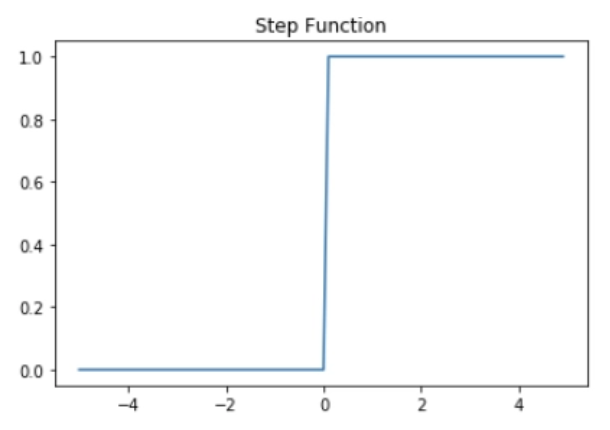
    - wx+b가 특정 값을 넘기면 1, 아니면 0을 출력함

3. 시그모이드 함수
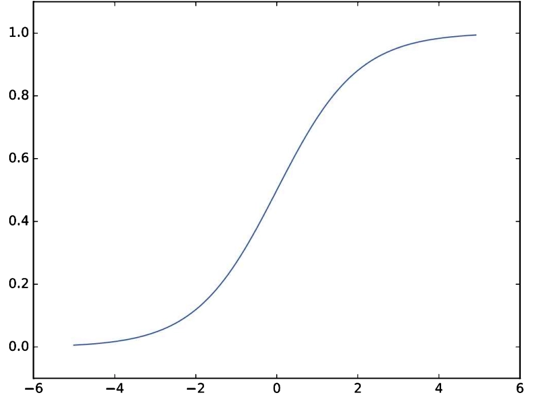
    - $$ f(x)=\frac{1}{1+e^{−x}} $$
    - 시그모이드 함수는 x에 따라 출력값이 연속적으로 변화하는 비선형 함수

4. ReLU 함수
    - $$ f(x)=max(0,x) $$
    - 입력이 0보다 크면 그대로, 0 이하면 0을 출력하는 비선형 함수
    - 계산이 간단하고 효율적이며, 비선형성을 제공하고, 기울기 소실 문제를 완화하기 때문에 ReLU함수를 가장 많이 사용

5. Tanh 함수
    - 시그모이드의 변형으로 출력값의 범위가 -1 에서 1 사이
    - 주로 입력값의 중심을 0으로 맞추고 싶을 때 사용
    - 입력값이 매우 크거나 매우 작으면 미분값이 0에 가까워져 기울기 소실 문제 발생

6. Softmax 함수
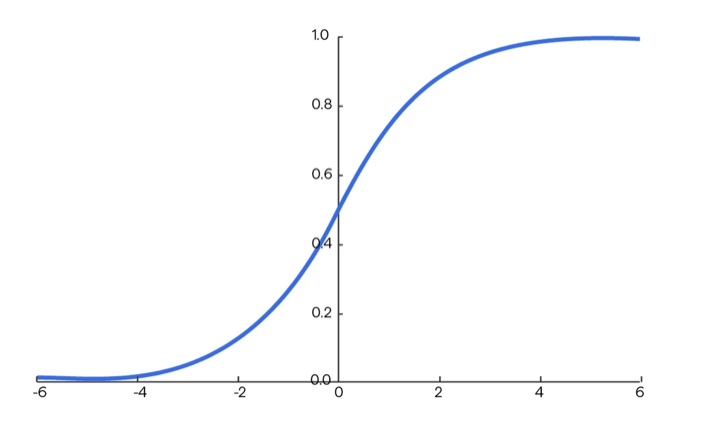
    - $$ f(x_i)=\frac{e^{x_i}}{∑_je^{x_j}} $$
    - 출력값이 모두 0~1사이이고, 전체 합이 1이 되기 때문에 각 클래스에 속할 확률을 볼 수 있다.
    - Softmax + 크로스 엔트로피 손실 함수의 조합은 예측확률과 정답 확률과의 차이를 계산할 수 있어 학습 효율이 높음


### 2-4 경사하강법

0. 기초 지식
    - 경사하강법을 통해서 오차를 가장 작게 만들어가지만, 보통 데이터가 너무 방대하면 메모리와 시간이 부족 -> 배치 사용
    - 배치
      - 학습 과정에서 가중치와 같은 매개 변수를 조정하기 위해 사용하는 데이터의 묶음을 의미하며, 하이퍼파라미터이다.
      - 배치 크기가 너무 큰 경우, 학습이 느려지고 메모리가 부족해질 수 있음
     - 배치 크기가 너무 작으면, 가중치가 자주 업데이트되어, 학습이 불안정해 질 수 있음

    -  에프크
      - 모든 데이터셋을 학습하는 횟수를 의미

    -  이터레이션 또는 스텝
      - 한 번의 에포크를 끝내기 위해서 필요한 배치의 수
      - 1 Epoch에서 다루는 데이터의 수 = 배치의 크기 * 이터레이션

1. 배치 경사하강법
    - 가장 기본적인 경사하강법으로, 오차를 구할 때 전체 데이터를 한 묶음으로 묶는다
    - 전체 데이터를 통해 학습시키기 때문에 업데이트 횟수가 적으며, 모든 데이터를 한번에 처리하기 때문에 메모리가 많이 필요함
    - 항상 같은 데이터에 대해 경사를 구하기 때문에 수렴이 안정적

2. 배치 크기가 1인 확률적 경사하강법
    - 기존의 경사 하강법은 전체 데이터에 대해서 계산을 하기 때문에 시간이 오래걸린다
    - 배치 크기가 1인 확률적 경사하강법은 랜덤으로 선택된 하나의 데이터에 대해서만 진행

3. 미니 배치 경사하강법
    - 배치 크기가 1인 경사 하강법은 정확도가 낮을 수 있기 때문에, 미니 배치 경사 하강법 사용
    - 일반적으로 2의 제곱수에 해당하는 숫자로 선택


### 2-5 옵티마이저

경사하강법을 더 효율적이고 안정적으로 수행하기 위해서 필요한 것

1. 모멘텀
    - 변수가 가던 방향으로 계속 가도록 속도를 추가
    
2. 알엠에스프롭
    - 기울기가 큰 방향에서는 너무 많이, 작은 방향에서는 너무 작게 이동하기 때문에 각각에 따른 학습률 조정

3. 아담
    - RMSProp과 Momentum을 합쳐 방향과 학습률 모두 잡음


### 2-6 데이터 증강

- 현실의 데이터는 다양하게 변형되고 조금씩 바뀌기 때문에 기존 데이터에서 변형을 통해 학습 데이터를 늘리는 것을 데이터 증강이라 함

- 모델 성능 향상, 데이터 의존성 감소, 과적합 완화, 데이터프라이버시 보호에 기여

---